In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms
from torch.utils.data import random_split, Dataset
# from translate.py import translate
import torchvision.models as models

import random
%matplotlib inline

In [2]:
class MyDataSet(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

In [3]:
data_dir = '/kaggle/input/datasets/ngocvnvuong/machine-learning/venom type-20260322T012421Z-1-001/venom type'

# Load toàn bộ dữ liệu từ thư mục chính
dataset = datasets.ImageFolder(data_dir, transform = transforms.Compose([
    transforms.Resize((288,288)),
    transforms.ToTensor(),
]))

print("Các loại nọc độc (Classes):", dataset.classes)

Các loại nọc độc (Classes): ['Neurotoxic venom', 'hemotoxic venom']


In [4]:
# --- CHIA TỈ LỆ 80% TRAIN - 20% TEST ---
random_seed = 45
torch.manual_seed(random_seed)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size  # Val_size ở đây đóng vai trò là tập Test 20%

train_ds, val_ds = random_split(dataset, [train_size, val_size])

print(f"Tổng số ảnh: {len(dataset)} | Train (80%): {len(train_ds)} | Test (20%): {len(val_ds)}")

Tổng số ảnh: 996 | Train (80%): 796 | Test (20%): 200


In [5]:
# Áp dụng Augmentation & Normalize
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))

train_set = MyDataSet(train_ds, transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(*stats, inplace=True),
]))

In [6]:
# Val_set (20% Test) không dùng HorizontalFlip để đánh giá cho khách quan
val_set = MyDataSet(val_ds, transform = transforms.Normalize(*stats, inplace=True))

batch_size = 8
# Nếu chạy trên Windows, đổi num_workers=0. Chạy Kaggle/Colab thì để 2 bình thường.
train_loader = DataLoader(train_set, batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, 16, num_workers=2, pin_memory=True)

In [7]:
# ==========================================
# 2. KIẾN TRÚC MẠNG (GIỮ NGUYÊN BẢN GỐC)
# ==========================================
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    valid_preds = torch.sum(preds == labels).item()
    all_preds = len(preds)
    return torch.tensor(valid_preds/all_preds)

class ModelBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], last_lr: {:.5f}, train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['lrs'][-1], result['train_loss'], result['val_loss'], result['val_acc']))

def conv_block(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
              nn.BatchNorm2d(out_channels),
              nn.ReLU(inplace=True)]
    if pool: layers.append(nn.MaxPool2d(5))
    return nn.Sequential(*layers)

class Model1(ModelBase):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool=True)
        self.res1 = nn.Sequential(conv_block(128, 128), conv_block(128, 128))
        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True)
        self.res2 = nn.Sequential(conv_block(512,512), conv_block(512, 512))
        self.classifier = nn.Sequential(nn.MaxPool2d(2),
                                        nn.Flatten(),
                                        nn.Linear(512, num_classes))

    def forward(self, xb):
        out = self.conv1(xb)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out

In [8]:
# ==========================================
# 3. QUẢN LÝ THIẾT BỊ (GPU) VÀ HÀM HUẤN LUYỆN
# ==========================================
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)
    def __len__(self):
        return len(self.dl)

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def fit_one_cycle(epochs, max_lr, model, train_loader, val_loader, weight_decay=0, grad_clip=None, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    history = []
    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_loader))

    for epoch in range(epochs):
        model.train()
        train_losses = []
        lrs = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)
            optimizer.step()
            optimizer.zero_grad()
            lrs.append(get_lr(optimizer))
            sched.step()

        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)
    return history

def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation/Test'])
    plt.title('Loss vs. No. of epochs')
    plt.show()

def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs')
    plt.show()

In [9]:
# ==========================================
# 4. THỰC THI TOÀN BỘ QUÁ TRÌNH
# ==========================================
device = get_default_device()
print(f"Đang chạy trên thiết bị: {device}")

# Đưa Data lên thiết bị
train_loader = DeviceDataLoader(train_loader, device)
val_loader = DeviceDataLoader(val_loader, device)

# Khởi tạo mô hình (3 kênh màu, 2 class đầu ra: Hemotoxic và Neurotoxic)
model = Model1(3, 2)
to_device(model, device)

# Siêu tham số
epochs = 15
max_lr = 0.005
grad_clip = 0.1
weight_decay = 1e-5
opt_func = torch.optim.Adam

print("\n=> BẮT ĐẦU HUẤN LUYỆN (Train 80% - Test 20%)")
history = fit_one_cycle(epochs, max_lr, model, train_loader, val_loader,
                        grad_clip=grad_clip,
                        weight_decay=weight_decay,
                        opt_func=opt_func)

print("\n=> ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST (20%):")
final_eval = evaluate(model, val_loader)
print(final_eval)

Đang chạy trên thiết bị: cuda

=> BẮT ĐẦU HUẤN LUYỆN (Train 80% - Test 20%)
Epoch [0], last_lr: 0.00075, train_loss: 0.7054, val_loss: 0.8560, val_acc: 0.6154
Epoch [1], last_lr: 0.00217, train_loss: 0.7796, val_loss: 0.4970, val_acc: 0.7788
Epoch [2], last_lr: 0.00380, train_loss: 0.8248, val_loss: 0.8740, val_acc: 0.6587
Epoch [3], last_lr: 0.00485, train_loss: 0.9245, val_loss: 2.8958, val_acc: 0.6250
Epoch [4], last_lr: 0.00497, train_loss: 0.8908, val_loss: 0.6436, val_acc: 0.7260
Epoch [5], last_lr: 0.00475, train_loss: 0.7993, val_loss: 1.0568, val_acc: 0.4663
Epoch [6], last_lr: 0.00433, train_loss: 0.7093, val_loss: 0.5043, val_acc: 0.7404
Epoch [7], last_lr: 0.00375, train_loss: 0.6948, val_loss: 0.5139, val_acc: 0.7500
Epoch [8], last_lr: 0.00306, train_loss: 0.4986, val_loss: 0.4073, val_acc: 0.8173
Epoch [9], last_lr: 0.00231, train_loss: 0.5564, val_loss: 0.4991, val_acc: 0.8221
Epoch [10], last_lr: 0.00159, train_loss: 0.4389, val_loss: 0.9906, val_acc: 0.7500
Epoch [11]

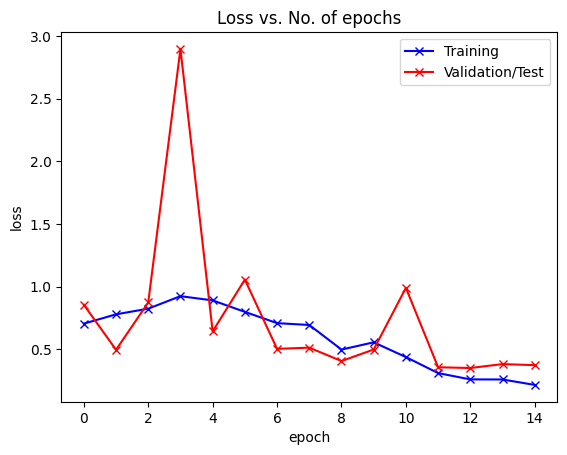

In [10]:
plot_losses(history)

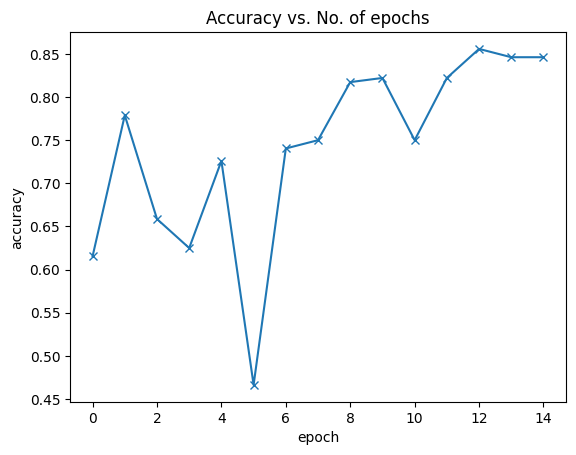

In [11]:
plot_accuracies(history)

Lấy ngẫu nhiên 10 con rắn để AI phân loại


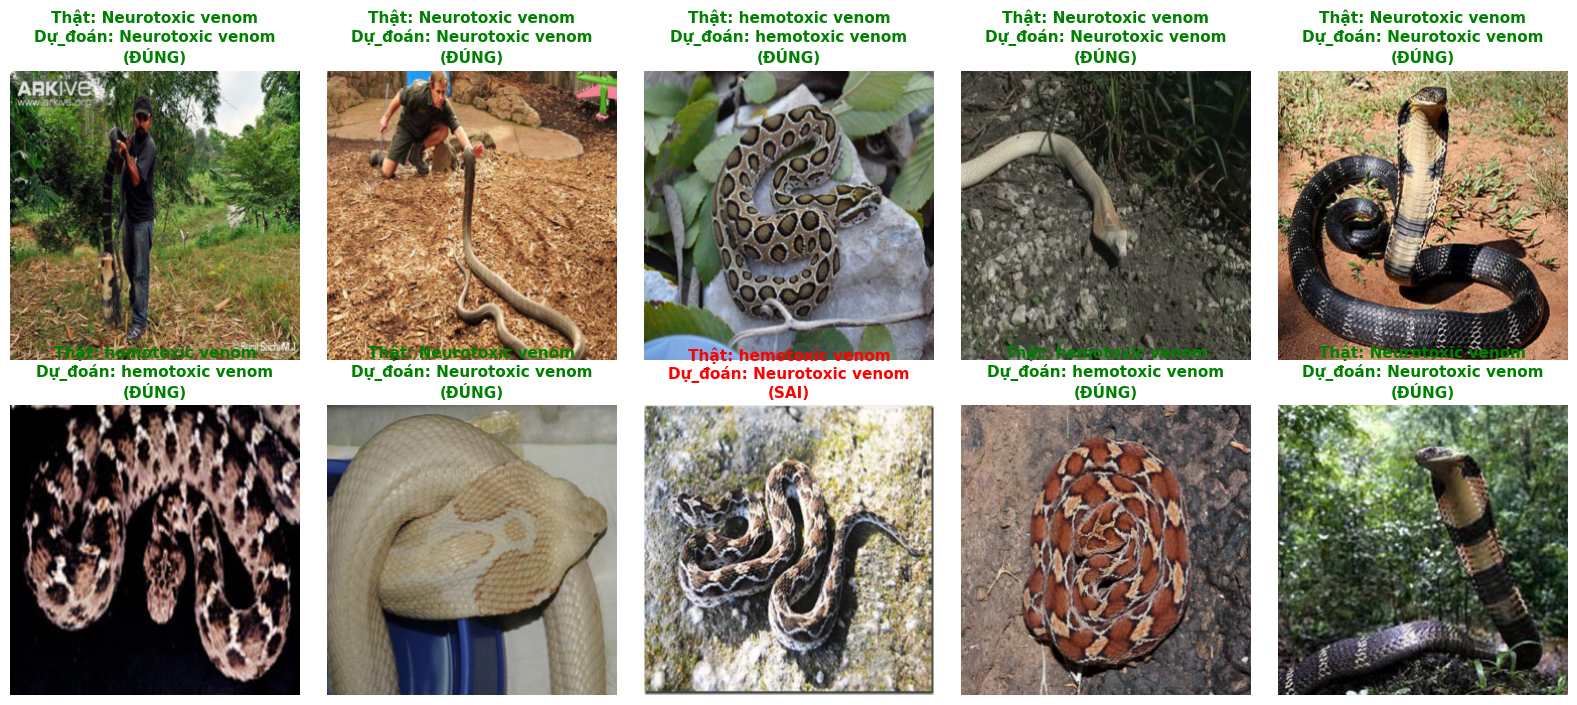

In [12]:
import random
import matplotlib.pyplot as plt
import torch

print("Lấy ngẫu nhiên 10 con rắn để AI phân loại")

#In ra tên loại độc
classes = dataset.classes

# Đồ thị gồm  2 hàng x 5 cột (10 ảnh)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

#Đưa AI sang chế độ test
model.eval()

with torch.no_grad(): # Tắt tính toán đạo hàm để chạy siêu tốc
    for i in range(10):
        random_idx = random.randint(0, len(val_set) - 1)
    
        img_display, actual_label_idx = val_ds[random_idx] 
        
        img_predict, _ = val_set[random_idx]               
        
        xb = img_predict.unsqueeze(0).to(device)
        
#Đây chính là phán đoán của AI
        yb = model(xb)
        _, preds = torch.max(yb, dim=1)
        predicted_label_idx = preds[0].item()
        
        actual_name = classes[actual_label_idx]
        predicted_name = classes[predicted_label_idx]
        
        # Đưa hình ảnh lên lưới
        ax = axes[i]
        ax.imshow(img_display.permute(1, 2, 0))
        ax.axis('off')
        
        # Xanh = Đúng, Đỏ = Sai
        if actual_name == predicted_name:
            color = 'green'
            result_text = "ĐÚNG"
        else:
            color = 'red'
            result_text = "SAI"
            
        title = f"Thật: {actual_name}\nDự_đoán: {predicted_name}\n({result_text})"
        ax.set_title(title, color=color, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

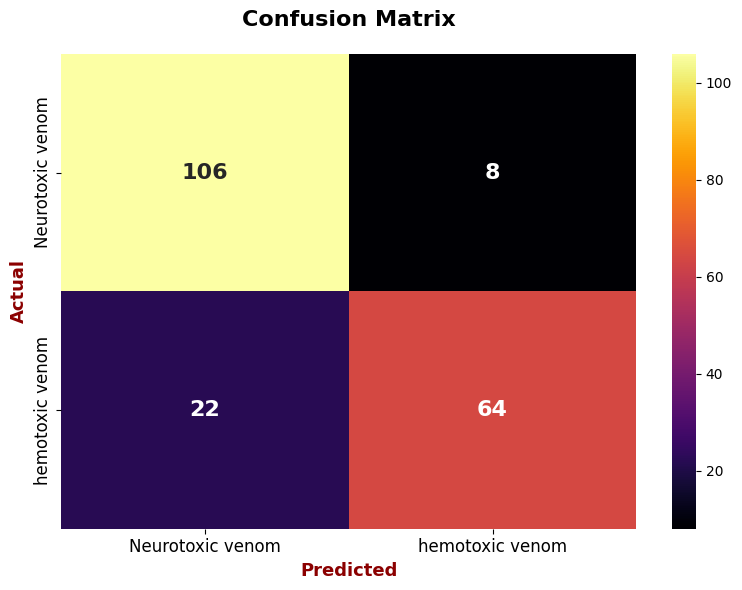


BÁO CÁO CHI TIẾT:
                  precision    recall  f1-score   support

Neurotoxic venom       0.83      0.93      0.88       114
 hemotoxic venom       0.89      0.74      0.81        86

        accuracy                           0.85       200
       macro avg       0.86      0.84      0.84       200
    weighted avg       0.85      0.85      0.85       200



In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
model.eval()
import torch
import matplotlib.pyplot as plt
import numpy as np
model.eval()

y_true = [] # Chứa đáp án thật
y_hat = [] # Chứa đáp án AI đoán

# Tắt tính toán đạo hàm để chạy siêu tốc
with torch.no_grad():
    for images, labels in val_loader: 
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_hat.extend(predicted.cpu().numpy())

#Ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_hat)

# Tên các loại nọc độc
class_names = dataset.classes

#Vẽ biểu đồ nhiệt
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='inferno', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 16, "weight": "bold"}) # Chữ số to, in đậm

plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted', fontsize=13, fontweight='bold', color='darkred')
plt.ylabel('Actual', fontsize=13, fontweight='bold', color='darkred')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

from sklearn.metrics import classification_report
print("\nBÁO CÁO CHI TIẾT:")
print(classification_report(y_true, y_hat, target_names=class_names))

=> Đang khởi tạo mô hình Grad-CAM...
=> Bốc ngẫu nhiên 1 ảnh rắn từ tập Test để vẽ Grad-CAM...


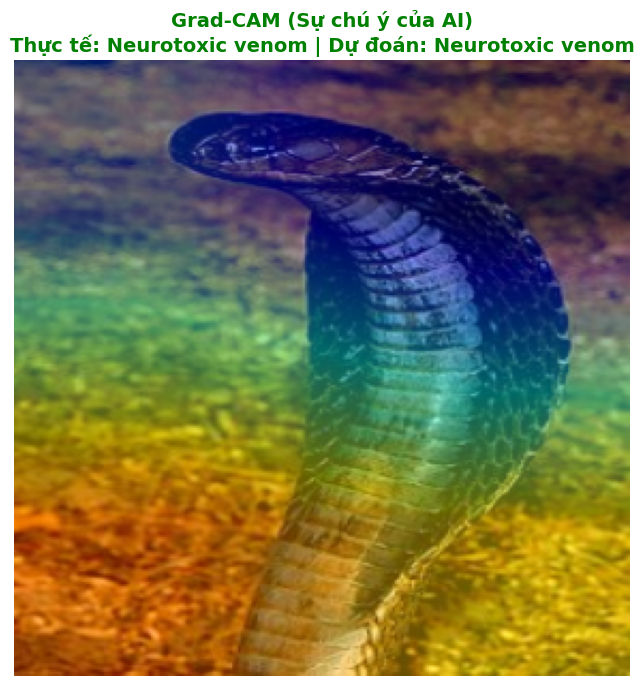

In [14]:
import cv2
from PIL import Image
# ==========================================
# GIAI ĐOẠN 1: ĐỊNH NGHĨA LỚP GRAD-CAM
# ==========================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Thiết lập hooks để thu thập dữ liệu khi AI forward/backward
        self.target_layer.register_forward_hook(self.save_activations)
        self.target_layer.register_full_backward_hook(self.save_gradients)

    def save_activations(self, module, input, output):
        self.activations = output.detach()

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_heatmap(self, input_image, class_idx=None):
        self.model.eval()
        # Forward pass
        output = self.model(input_image)

        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        # Backward pass để tính gradients cho lớp mục tiêu
        self.model.zero_grad()
        class_loss = output[0, class_idx]
        class_loss.backward()

        # Tính toán trọng số (neuron importance weights) bằng cách lấy trung bình gradients
        weights = torch.mean(self.gradients, dim=[2, 3])
        
        # Tạo heatmap bằng cách nhân activations với trọng số
        heatmap = torch.sum(weights[0, :, None, None] * self.activations[0], dim=0)
        
        # Áp dụng ReLU để chỉ lấy các đặc trưng tích cực đóng góp vào lớp đó
        heatmap = torch.maximum(heatmap, torch.tensor(0.0))
        
        # Chuẩn hóa về khoảng [0, 1]
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().numpy(), class_idx

# ==========================================
# GIAI ĐOẠN 2: HÀM VẼ GRAD-CAM PURE LÊN ẢNH GỐC
# ==========================================
def show_gradcam(img_tensor, heatmap, actual_label, predicted_label, classes):
    # Chuyển tensor thành ảnh NumPy gốc (H, W, C)
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    
    # 1. Normalize ngược (Un-normalize) để ảnh hiện lên đúng màu sắc
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = std * img + mean
    img = np.clip(img, 0, 1) # Giới hạn trong khoảng [0, 1]
    
    # Chuyển về dạng uint8 (0-255) để OpenCV xử lý
    img = np.uint8(255 * img)
    height, width, _ = img.shape

    # 2. Xử lý heatmap
    heatmap = cv2.resize(heatmap, (width, height)) # Resize về bằng ảnh gốc
    heatmap = np.uint8(255 * heatmap) # Chuyển về 0-255
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET) # Áp dụng màu quét nhiệt (Jet)

    # 3. Phủ heatmap lên ảnh gốc (tỉ lệ 60% ảnh - 40% heatmap)
    superimposed_img = heatmap * 0.4 + img * 0.6
    superimposed_img = superimposed_img / np.max(superimposed_img) # Chuẩn hóa lại để vẽ

    # 4. Vẽ kết quả
    plt.figure(figsize=(10, 8))
    plt.imshow(superimposed_img)
    plt.axis('off')
    
    ten_thuc_te = classes[actual_label]
    ten_du_doan = classes[predicted_label]
    title_color = 'green' if actual_label == predicted_label else 'red'
    
    title = f"Grad-CAM (Sự chú ý của AI)\nThực tế: {ten_thuc_te} | Dự đoán: {ten_du_doan}"
    plt.title(title, fontsize=14, fontweight='bold', color=title_color)
    plt.show()

# ==========================================
# GIAI ĐOẠN 3: THỰC THI (BỐC 1 ẢNH NGẪU NHIÊN VÀ VẼ)
# ==========================================
print("=> Đang khởi tạo mô hình Grad-CAM...")
# Chỉ định lớp mục tiêu là model.res2 (Lớp tích chập cuối của Model1)
target_layer = model.res2
cam_generator = GradCAM(model, target_layer)

print("=> Bốc ngẫu nhiên 1 ảnh rắn từ tập Test để vẽ Grad-CAM...")
import random
random_idx = random.randint(0, len(val_set) - 1)

# Lấy ảnh (Lấy từ val_set vì nó đã có Tensor sẵn)
img_predict, actual_label = val_set[random_idx]

# Đưa ảnh vào thiết bị và thêm chiều batch
input_image = img_predict.unsqueeze(0).to(device)

# Tạo heatmap
heatmap, predicted_label = cam_generator.generate_heatmap(input_image)

# Vẽ Grad-CAM
show_gradcam(img_predict, heatmap, actual_label, predicted_label, dataset.classes)

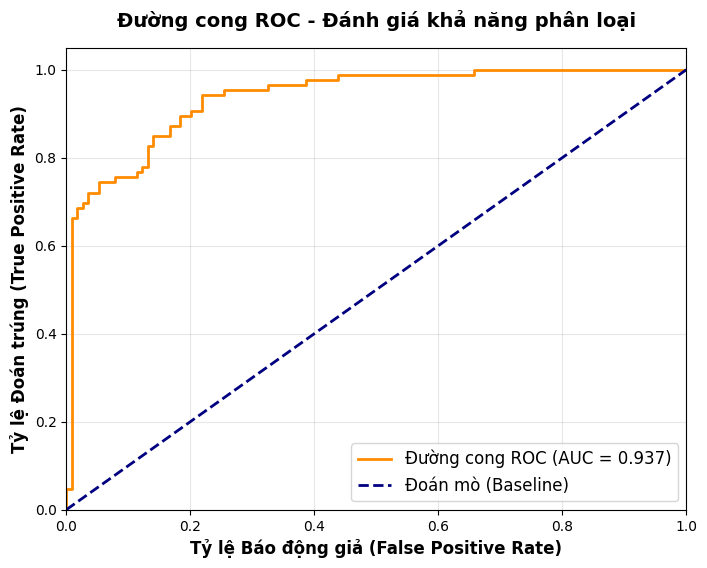

=> Chỉ số AUC (Area Under Curve) của mô hình là: 0.937
Mô hình phân biệt 2 loại nọc độc cực kỳ tối ưu.


In [15]:
import random
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_curve, auc
import numpy as np
#Vẽ đường cong ROC & tính AUC

y_true = []
y_scores = [] # ROC cần xác suất (probabilities), không phải nhãn cứng (labels)

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        # Lấy xác suất của lớp Positive (ở đây là class thứ 1, ví dụ Neurotoxic)
        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1) # Chuyển output thành dạng %
        
        y_true.extend(labels.cpu().numpy())
        y_scores.extend(probabilities[:, 1].cpu().numpy()) # Lấy cột xác suất của class 1

# Tính toán các điểm trên đường cong ROC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Vẽ biểu đồ
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Đường cong ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Đoán mò (Baseline)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Báo động giả (False Positive Rate)', fontsize=12, fontweight='bold')
plt.ylabel('Tỷ lệ Đoán trúng (True Positive Rate)', fontsize=12, fontweight='bold')
plt.title('Đường cong ROC - Đánh giá khả năng phân loại', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"=> Chỉ số AUC (Area Under Curve) của mô hình là: {roc_auc:.3f}")
if roc_auc > 0.9:
    print("Mô hình phân biệt 2 loại nọc độc cực kỳ tối ưu.")
elif roc_auc > 0.8:
    print("Mô hình hoạt động ổn định.")
else:
    print("Mô hình chưa tối ưu vì còn nhầm lẫn nhiều.")

Đã trích xuất 200 bức ảnh.
Mỗi bức ảnh được AI biểu diễn bằng không gian 512 chiều.

Đang dùng thuật toán t-SNE ép xuống 2 chiều... (Mất khoảng vài giây)


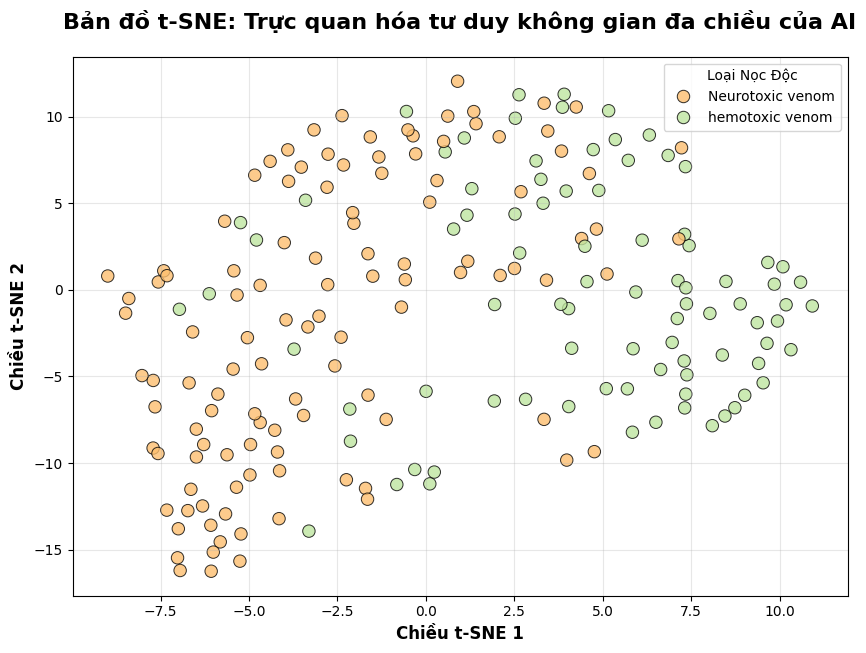

In [16]:
from sklearn.manifold import TSNE
import seaborn as sns
import pandas as pd
import numpy as np

features = []
targets = []

def hook_fn(module, input, output):
    features.append(output.detach().cpu().numpy())

# Gắn hook vào lớp Flatten (lớp áp chót của mô hình Model1 của bạn)
handle = model.classifier[1].register_forward_hook(hook_fn)

model.eval()
with torch.no_grad():
    for images, labels in val_loader: # Bắt AI làm bài thi trên tập Test
        _ = model(images) 
        targets.extend(labels.cpu().numpy())

# Tháo hook ra sau khi dùng xong
handle.remove()

features = np.concatenate(features)
targets = np.array(targets)

print(f"Đã trích xuất {features.shape[0]} bức ảnh.")
print(f"Mỗi bức ảnh được AI biểu diễn bằng không gian {features.shape[1]} chiều.")

# 2. DÙNG t-SNE ÉP XUỐNG CÒN 2 CHIỀU
print("\nĐang dùng thuật toán t-SNE ép xuống 2 chiều... (Mất khoảng vài giây)")
# perplexity: chỉnh độ gom cụm, thường từ 5 đến 50. Nếu dữ liệu ít thì để tầm 10-30.
tsne = TSNE(n_components=2, random_state=42, perplexity=30) 
tsne_results = tsne.fit_transform(features)

# 3. ĐÓNG GÓI DỮ LIỆU ĐỂ VẼ
df_tsne = pd.DataFrame()
df_tsne['Trục X'] = tsne_results[:,0]
df_tsne['Trục Y'] = tsne_results[:,1]

# Phiên dịch nhãn từ số (0, 1) sang tên chữ để chú thích cho đẹp
class_names = dataset.classes
df_tsne['Loại Nọc Độc'] = [class_names[t] for t in targets]

# 4. VẼ BIỂU ĐỒ PHÂN CỤM
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="Trục X", y="Trục Y",
    hue="Loại Nọc Độc",
    palette=sns.color_palette("Spectral", len(class_names)),
    data=df_tsne,
    legend="full",
    alpha=0.8,
    s=80,
    edgecolor='black'
)

plt.title('Bản đồ t-SNE: Trực quan hóa tư duy không gian đa chiều của AI', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Chiều t-SNE 1', fontsize=12, fontweight='bold')
plt.ylabel('Chiều t-SNE 2', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()
